# RetailPulse AI Retail Analytics

## Notebook 2: Exploratory Data Analysis (EDA)

### Objectives
- Load cleaned dataset
- Understand sales patterns
- Analyze customers and products
- Identify business trends
- Detect outliers
- Generate business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Graph style
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [3]:
print("Shape :", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape : (779425, 9)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  object 
 2   Description  779425 non-null  object 
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  object 
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  int64  
 7   Country      779425 non-null  object 
 8   TotalPrice   779425 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 53.5+ MB


In [4]:
df.describe()

,Invoice,Quantity,Price,Customer ID,TotalPrice
count,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,537426.828586,13.489370,3.218488,15320.360461,22.291823
std,26901.629627,145.855814,29.676140,1695.692775,227.427075
min,489434.000000,1.000000,0.001000,12346.000000,0.001000
25%,514483.000000,2.000000,1.250000,13971.000000,4.950000
50%,536754.000000,6.000000,1.950000,15247.000000,12.480000
75%,561995.000000,12.000000,3.750000,16794.000000,19.800000
max,581587.000000,80995.000000,10953.500000,18287.000000,168469.600000


### Observation

This statistical summary provides information about the distribution of Quantity, Price, Customer ID, and TotalPrice. It helps identify unusually large values that may require further investigation.

In [5]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

In [6]:
total_revenue = df["TotalPrice"].sum()

print(f"Total Revenue : £{total_revenue:,.2f}")

Total Revenue : £17,374,804.27


In [7]:
print("Unique Customers :", df["Customer ID"].nunique())

Unique Customers : 5878


In [8]:
print("Unique Products :", df["StockCode"].nunique())

Unique Products : 4631


In [9]:
print("Total Orders :", df["Invoice"].nunique())

Total Orders : 36969


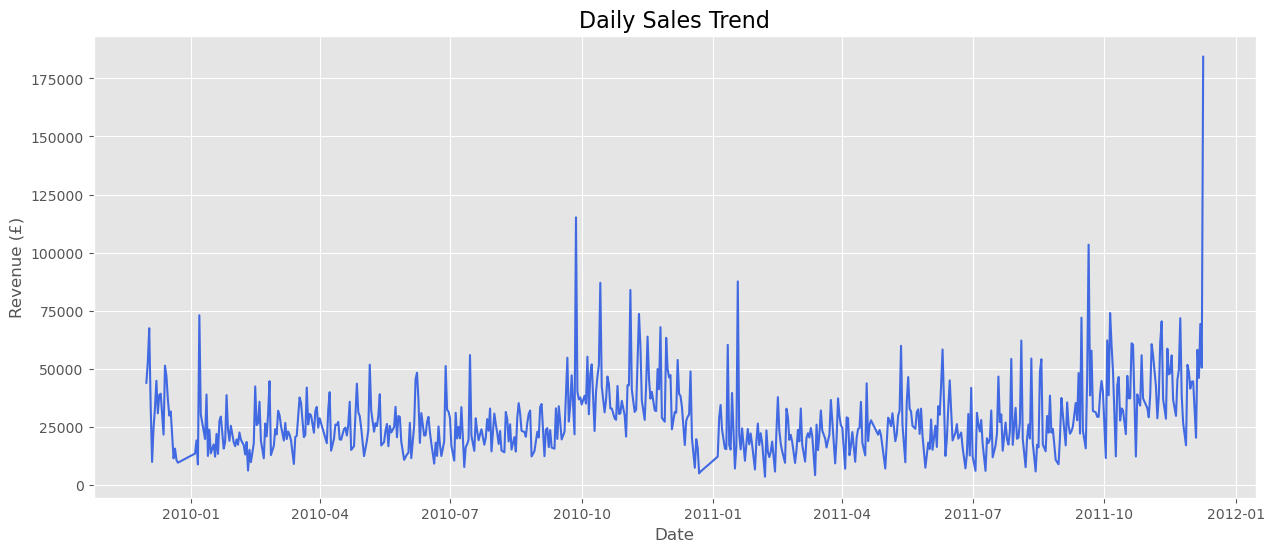

In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
daily_sales = df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"].sum()
plt.figure(figsize=(15,6))

daily_sales.plot(color="royalblue")

plt.title("Daily Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.grid(True)

plt.show()

### Business Insight

The daily sales trend helps identify fluctuations in revenue over time. Peaks may indicate seasonal demand, promotions, or holidays, while sudden drops may highlight operational issues or low customer activity.

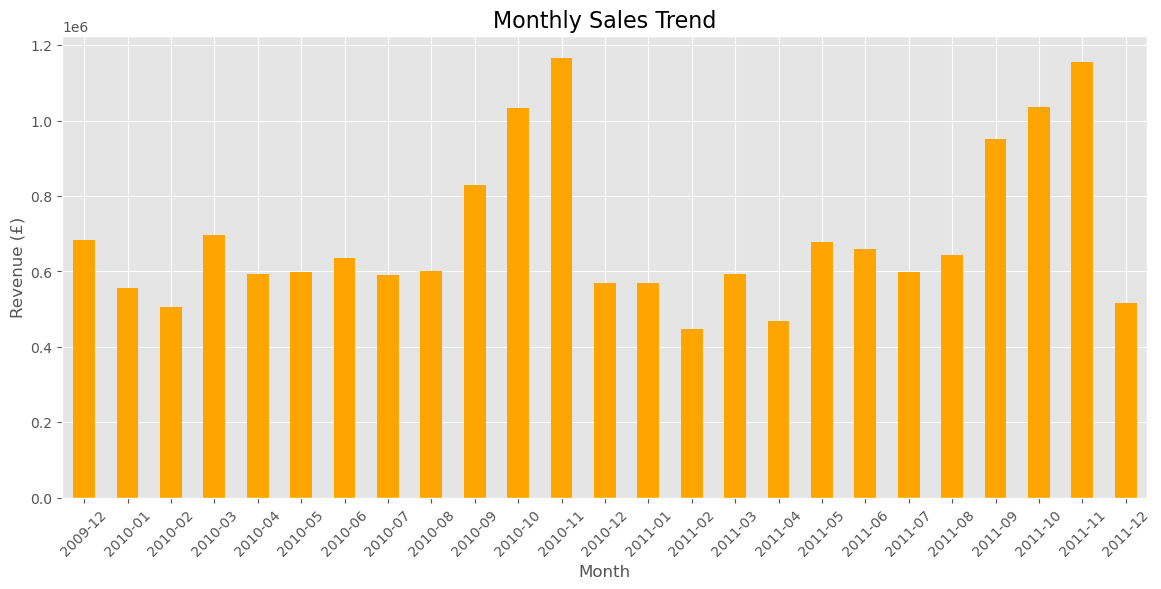

In [14]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()

monthly_sales.index = monthly_sales.index.astype(str)
plt.figure(figsize=(14,6))

monthly_sales.plot(kind="bar", color="orange")

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

### Business Insight

Monthly sales analysis helps understand seasonal purchasing behavior. Businesses can use this information to plan inventory, marketing campaigns, and staffing during high-demand months.

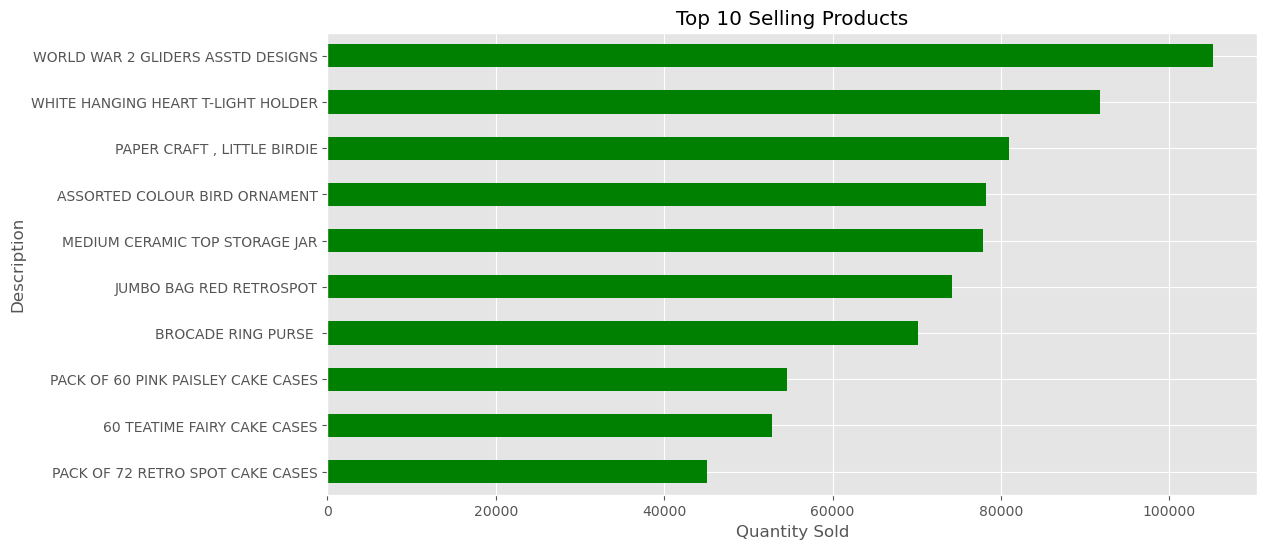

In [16]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh", color="green")

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")

plt.show()

### Business Insight

Identifying the top-selling products enables businesses to prioritize inventory management, optimize marketing strategies, and maximize revenue from high-performing products.

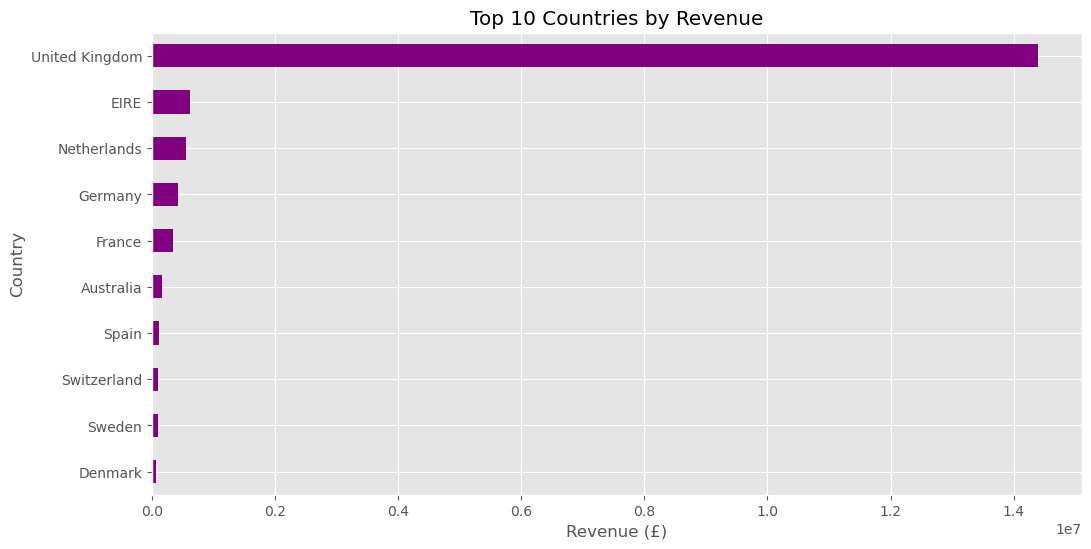

In [17]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.sort_values().plot(kind="barh", color="purple")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.show()

### Business Insight

The United Kingdom is expected to contribute the highest revenue. Country-wise analysis helps businesses identify profitable markets and expand strategically.

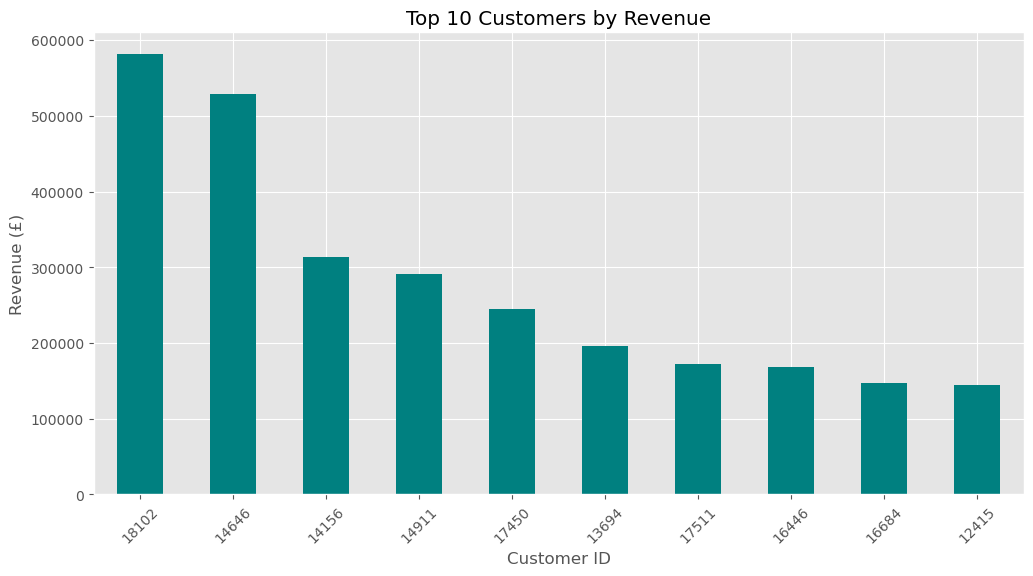

In [18]:
top_customers = df.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar", color="teal")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

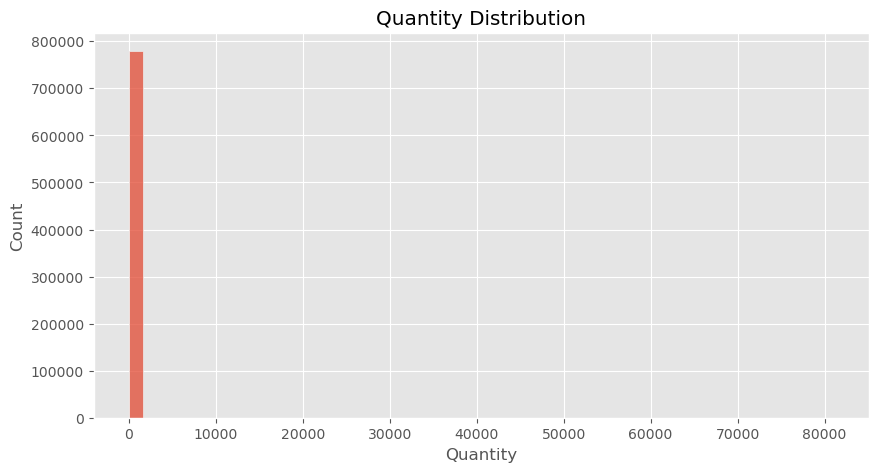

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df["Quantity"], bins=50)

plt.title("Quantity Distribution")

plt.show()

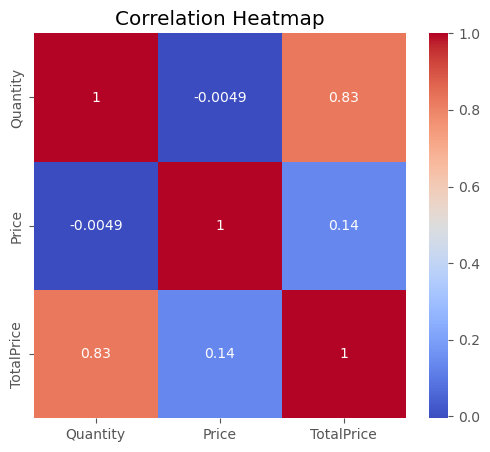

In [21]:
numeric_df = df[["Quantity", "Price", "TotalPrice"]]

plt.figure(figsize=(6,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

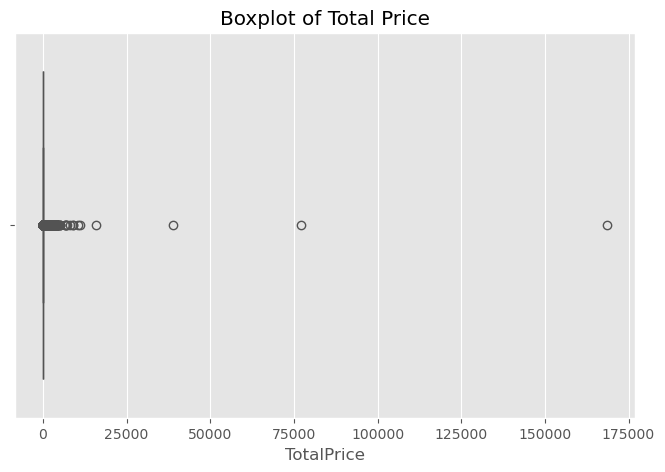

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["TotalPrice"])

plt.title("Boxplot of Total Price")

plt.show()

In [23]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["TotalPrice"] < lower) | (df["TotalPrice"] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 63562


# Key Business Insights

- The business generated over £17 million in revenue.
- More than 5,800 customers contributed to sales.
- The United Kingdom is the dominant market.
- A small number of customers generate a large share of revenue.
- Several products consistently drive high sales volume.
- Sales show seasonal fluctuations, indicating demand patterns.
- Outliers exist in transaction values and should be handled carefully before model training.